# LangGraph + Sqlite 

### Problem Statement

Build a **stateful chat assistant using LangGraph in Python** that maintains conversation history across multiple interactions.

The chat assistant should:

1. Accept messages from the user.
2. Generate a response using an LLM.
3. Maintain the conversation history in the LangGraph state.
4. Use a **SQLite checkpointer** to persist the graph state.
5. Use a `thread_id` to identify and maintain separate conversations.
6. Allow the conversation to be resumed later using the same `thread_id`.
7. Support multiple users/conversations without mixing their conversation histories.

**Workflow:**

```text
START → Chat Assistant → END


In [16]:
!pip install langgraph-checkpoint-sqlite

  Using cached aiosqlite-0.22.1-py3-none-any.whl.metadata (4.3 kB)
Using cached aiosqlite-0.22.1-py3-none-any.whl (17 kB)

   ---------------------------------------- 3/3 [langgraph-checkpoint-sqlite]



In [67]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from operator import add

# Sqlite imports
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

In [68]:
load_dotenv()

True

In [69]:
# Connect to SQLite. It automatically creates 'chatbot.db' if it doesn't exist.
conn = sqlite3.connect("chatbot.db", check_same_thread=False)

#### **The Necessity of `check_same_thread=False`**

By default, SQLite restricts database operations to the exact operating system thread that initialized the connection. This is a safety feature to prevent thread conflicts.

However, **LangGraph uses multi-threading** to run concurrently and handle multiple conversation flows and API calls. If `check_same_thread` is left as `True` (default), the program will crash with threading errors when a background thread tries to write to the database. Setting `check_same_thread=False` removes this constraint, allowing LangGraph to read and write database records across different concurrent threads.

In [70]:
class MessageSchema(BaseModel):
    messages: BaseMessage = Field(description='This field stores the message of llm and human')

In [71]:
class MessageState(TypedDict):
    messages: Annotated[list[BaseMessage], add]

In [72]:
model = ChatOpenAI(model='gpt-5.4-mini')

In [73]:
chatbot_model = model.with_structured_output(MessageSchema)

In [74]:
memory = SqliteSaver(conn)

In [157]:
def get_message(state: MessageState):
    messages = state['messages']
    query = messages[-1].content
    message = model.invoke(f"""
    You are a helpful assistant. Respond to the query given by the user.
    consider the current turn as the last message and all other messages for your context.
    query: {messages}
    """)

    print("-----------------------------------")
    for msg in messages:
        print(msg.content)
    print("-----------------------------------")
    
    return {'messages': [message]}

In [158]:
graph = StateGraph(MessageState)

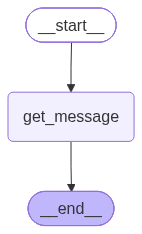

In [159]:
# nodes
graph.add_node('get_message', get_message)

# edges
graph.add_edge(START, 'get_message')
graph.add_edge('get_message', END)

# compile
workflow = graph.compile(checkpointer=memory)

workflow

In [160]:
config = {"configurable": {"thread_id": 1}}
# input_state = {'messages': [HumanMessage('Hi')]}
# res = workflow.invoke(input=input_state, config=config)
# res

In [162]:
config = {"configurable": {"thread_id": 8}}
while True:
    query = input('Human:')
    if query.lower()=='quit':
        break
    res = workflow.invoke(input={'messages': [HumanMessage(query)]}, config=config)
    print(f"Agent: {res['messages'][-1].content}")
    

Human: Hi


-----------------------------------
Hi
-----------------------------------
Agent: Hi! How can I help you today?


Human: I am snehadeep


-----------------------------------
Hi
Hi! How can I help you today?
I am snehadeep
-----------------------------------
Agent: Hi Snehadeep! How can I help you today?


Human: Who am i?


-----------------------------------
Hi
Hi! How can I help you today?
I am snehadeep
Hi Snehadeep! How can I help you today?
Who am i?
-----------------------------------
Agent: You are **Snehadeep**.


Human: quit


In [163]:
workflow.get_state({'configurable': {'thread_id': 8}})

StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hi! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 59, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EHlsrHFDxDppOVKziyTw59mz73CG9', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a04767-519e-71a2-a2ce-7b85496ee79f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 12, 'total_tokens': 71, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio'

In [166]:
for a in workflow.get_state_history({'configurable': {'thread_id': 8}}):
    print()
    print(a)


StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hi! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 59, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EHlsrHFDxDppOVKziyTw59mz73CG9', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a04767-519e-71a2-a2ce-7b85496ee79f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 12, 'total_tokens': 71, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio